# Harness completo
En este notebook se unen las 3 métricas para el harness

---
## Seccion 0 - Setup y reproducibilidad

In [ ]:
import subprocess, sys

pkgs = ["groq", "peft", "datasets", "transformers", "accelerate", "torchao"]
for pkg in pkgs:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", pkg])


In [2]:
import re, json, random, time
from pathlib import Path
import itertools
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification
from peft import PeftModel
from scipy.optimize import linear_sum_assignment

from groq import Groq
from datasets import load_from_disk

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Seeds fijadas. Device:", device)

print("Versiones de librerías:")
import transformers as _tr, datasets as _ds, peft as _peft
print(f"  transformers: {_tr.__version__}")
print(f"  datasets:     {_ds.__version__}")
print(f"  peft:         {_peft.__version__}")
print(f"  torch:        {torch.__version__}")
print(f"  numpy:        {np.__version__}")

Seeds fijadas. Device: cuda
Versiones de librerías:
  transformers: 5.16.1
  datasets:     4.0.0
  peft:         0.20.0
  torch:        2.11.0+cu128
  numpy:        2.1.3


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import transformers, peft
print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
print("peft        :", peft.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
torch       : 2.11.0+cu128
transformers: 5.16.1
peft        : 0.20.0


---
## Seccion 1 - Rutas del proyecto

In [52]:
# Raiz del proyecto en Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/TopicosIA/Proyecto-Salud")

# Adaptador LoRA de Clinical BERT -- cargado desde Google Drive
# Contiene: adapter_config.json, adapter_model.safetensors, tokenizer.json
MODEL_DIR = PROJECT_ROOT / "M1" / "saved_models" / "clinical_bert-distemist-lora"

# Gold set generado en 01_dataset_preparation.ipynb
# Formato JSONL: {"input": str, "esperado": list[str], "criterio": str}
GOLD_SET_PATH = PROJECT_ROOT / "M2" / "eval_harness" / "gold_examples.jsonl"

# Carpeta de salida
OUTPUT_DIR = PROJECT_ROOT / "M2" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Resultados de las métricas
DIM1_PATH  = OUTPUT_DIR / "resultado_dimension1.json"
DIM1B_PATH = OUTPUT_DIR / "resultado_dimension1b.json"
JUDGE_PATH = OUTPUT_DIR / "resultado_judge.json"

print("Proyecto en:", PROJECT_ROOT)
print()

print("Modelo (Drive):", MODEL_DIR)
print("  adapter_config existe:", (MODEL_DIR / "adapter_config.json").exists())
print("  adapter_model existe: ", (MODEL_DIR / "adapter_model.safetensors").exists())
print()
print("Gold set:", GOLD_SET_PATH)
print("  existe:", GOLD_SET_PATH.exists())
print()
print("Output:", OUTPUT_DIR)

Proyecto en: /content/drive/MyDrive/TopicosIA/Proyecto-Salud

Modelo (Drive): /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M1/saved_models/clinical_bert-distemist-lora
  adapter_config existe: True
  adapter_model existe:  True

Gold set: /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/eval_harness/gold_examples.jsonl
  existe: True

Output: /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/outputs


---
## Seccion 2 - Cargar el gold set

In [5]:
# El gold set es JSONL generado con select_rich_examples(n=75, min_entities=5, split="test")
assert GOLD_SET_PATH.exists(), (
    "Gold set no encontrado en " + str(GOLD_SET_PATH) + "\n"
    "Correr la celda de generacion de gold set en 01_dataset_preparation.ipynb primero."
)

gold_examples = []
with open(GOLD_SET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            gold_examples.append(json.loads(line))

print(f"Gold set cargado: {len(gold_examples)} ejemplos")


Gold set cargado: 59 ejemplos


In [6]:
assert len(gold_examples) > 0, "El gold set esta vacio"
assert "input" in gold_examples[0],    "Falta campo input en el gold set"
assert "esperado" in gold_examples[0], "Falta campo esperado en el gold set"
assert isinstance(gold_examples[0]["esperado"], list), (
    "esperado debe ser list[str], vino como " + str(type(gold_examples[0]["esperado"]))
)

print("Formato valido")
print("Primer ejemplo:")
print("  input[:120]:", gold_examples[0]["input"][:120], "...")
print("  esperado:", gold_examples[0]["esperado"])
print("  n_entidades:", len(gold_examples[0]["esperado"]))


Formato valido
Primer ejemplo:
  input[:120]: Varón soltero de 37 años de edad, trabajador del campo, que es enviado a nuestro Servicio desde otro hospital por no ten ...
  esperado: ['adenopatías', 'adenopatías bilaterales en las cadenas iliacas interna y externa y en las cadenas inguinales', 'adenopatías bilaterales ilíacas e inguinales', 'afectación de las cadenas ganglionares', 'brucelosis', 'carcinoma verrugoso de Buscke-Lowenstein', 'condiloma acuminado gigante de Buschke-Lowenstein', 'herida de la incisión de linfadenectomía', 'hipogonadismo hipergonadotrópico', 'infiltraba igualmente los tejidos pubianos, el escroto', 'infiltración de la grasa del tejido celular subcutáneo de la pared interna de los muslos ni de la grasa del periné', 'infiltración metastásica', 'infiltrar también la fascia del músculo aductor', 'lesiones óseas en las ramas isquio-ileo-pubianas', 'lesión', 'lesión penoescrotal', 'lesión tumoral', 'linfogranuloma venéreo', 'lúes', 'masa tumoral', 'metástasis de c

---
## Seccion 3 - Cargar el modelo fine-tuneado (BERT + LoRA)

In [7]:
# Mismo esquema BIO que en M1 (03_finetuning.ipynb, MODEL_REGISTRY)
# Redeclarado explicitamente para no depender de que adapter_config.json lo persista
label_list = ["O", "B-ENFERMEDAD", "I-ENFERMEDAD"]
id2label   = {i: l for i, l in enumerate(label_list)}
label2id   = {l: i for i, l in enumerate(label_list)}
print("id2label:", id2label)


id2label: {0: 'O', 1: 'B-ENFERMEDAD', 2: 'I-ENFERMEDAD'}


In [8]:
# Checkpoint base -- igual al MODEL_REGISTRY["clinical_BERT"] de 03_finetuning.ipynb
BASE_CHECKPOINT = "PlanTL-GOB-ES/roberta-base-biomedical-clinical-es"

base_model = AutoModelForTokenClassification.from_pretrained(
    BASE_CHECKPOINT,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)
print("Modelo base cargado. Parametros totales:",
      sum(p.numel() for p in base_model.parameters()))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                       | Status     | 
--------------------------+------------+-
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
classifier.bias           | MISSING    | 
classifier.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo base cargado. Parametros totales: 125389827


In [9]:
import torch

# Inyectar el adaptador LoRA entrenado en M1
# PeftModel busca adapter_config.json y adapter_model.safetensors en MODEL_DIR
model = PeftModel.from_pretrained(base_model, str(MODEL_DIR))
model.eval()   # CRITICO: desactiva dropout para resultados deterministas

if torch.cuda.is_available():
    model = model.to("cuda")

print("Adaptador LoRA cargado")
print("Dispositivo:", next(model.parameters()).device)

Adaptador LoRA cargado
Dispositivo: cuda:0


In [10]:
# Cargar tokenizer desde MODEL_DIR (guardado junto al adaptador en M1 celda 38)
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))
print("Tokenizer cargado. Vocab size:", tokenizer.vocab_size)


Tokenizer cargado. Vocab size: 52000


In [11]:
# Sanity check con frase de juguete antes de evaluar el gold set completo
# Esperado: diabetes->B-ENFERMEDAD, mellitus->I-ENFERMEDAD, hipertension->B-ENFERMEDAD
frase_prueba = "El paciente presenta diabetes mellitus tipo 2 y antecedentes de hipertension arterial."
tokens_prueba = frase_prueba.split()

inputs_p = tokenizer(
    tokens_prueba, is_split_into_words=True, return_tensors="pt"
).to(model.device)

with torch.no_grad():
    logits_p = model(**inputs_p).logits

pred_ids_p = logits_p.argmax(dim=-1)[0].tolist()
word_ids_p = inputs_p.word_ids(batch_index=0)

print("Sanity check -- predicciones por palabra:")
seen = set()
for idx, wid in zip(pred_ids_p, word_ids_p):
    if wid is None or wid in seen:
        continue
    print(f"  {tokens_prueba[wid]:<25} -> {id2label[idx]}")
    seen.add(wid)


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Sanity check -- predicciones por palabra:
  El                        -> O
  paciente                  -> O
  presenta                  -> O
  diabetes                  -> B-ENFERMEDAD
  mellitus                  -> I-ENFERMEDAD
  tipo                      -> I-ENFERMEDAD
  2                         -> I-ENFERMEDAD
  y                         -> O
  antecedentes              -> O
  de                        -> O
  hipertension              -> B-ENFERMEDAD
  arterial.                 -> I-ENFERMEDAD


---
## Seccion 4 - Funciones reutilizadas de M1

In [12]:
import string

def normalizar_entidad(e):
    """Quita puntuacion de borde que es artefacto de tokenizar con .split()."""
    return e.lower().strip().strip(string.punctuation + " ")

In [13]:
# Copiado de 02_dataset_chunking_and_splits.ipynb -- NO MODIFICAR

WINDOW_WORDS = 277  # Misma ventana que en M1
OVERLAP_WORDS = 50  # Mismo solapamiento que en M1

def chunk_words(words, window_words, overlap_words):
    """
    Parte una lista de palabras en ventanas solapadas.
    Devuelve lista de (chunk_idx, sublist_de_palabras).
    El overlap evita perder entidades que caen en el borde entre chunks
    -- misma logica que chunk_record_by_words de NB2, sin el manejo de
    offsets de entidades porque aca no hace falta (gold es a nivel doc).
    """
    if len(words) <= window_words:
        return [(0, words)]

    chunks = []
    step = window_words - overlap_words
    start = 0
    idx = 0
    while start < len(words):
        chunk = words[start : start + window_words]
        chunks.append((idx, chunk))
        if start + window_words >= len(words):
            break
        start += step
        idx += 1
    return chunks

print("Funciones de chunking cargadas")

Funciones de chunking cargadas


In [14]:
# Copiado de 03_finetuning.ipynb -- NO MODIFICAR

def strip_chunk_suffix(doc_id):
    return re.sub(r"_chunk\d+$", "", doc_id)


def bio_to_entity_set(tokens, tags):
    entities, current = [], []
    for tok, tag in zip(tokens, tags):
        if tag == "B-ENFERMEDAD":
            if current:
                entities.append(" ".join(current))
            current = [tok]
        elif tag == "I-ENFERMEDAD" and current:
            current.append(tok)
        else:
            if current:
                entities.append(" ".join(current))
            current = []
    if current:
        entities.append(" ".join(current))
    return set(normalizar_entidad(e) for e in entities)


def aggregate_entities_by_original_doc(doc_ids, entity_sets):
    grouped = {}
    for doc_id, ents in zip(doc_ids, entity_sets):
        orig_id = strip_chunk_suffix(doc_id)
        grouped.setdefault(orig_id, set()).update(ents)
    return grouped


def micro_prf1_by_doc(true_by_doc, pred_by_doc):
    tp = fp = fn = 0
    all_doc_ids = set(true_by_doc) | set(pred_by_doc)
    for doc_id in all_doc_ids:
        true_ents = true_by_doc.get(doc_id, set())
        pred_ents = pred_by_doc.get(doc_id, set())
        tp += len(true_ents & pred_ents)
        fp += len(pred_ents - true_ents)
        fn += len(true_ents - pred_ents)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"precision": precision, "recall": recall, "f1": f1,
            "tp": tp, "fp": fp, "fn": fn}

print("Funciones de M1 cargadas")


Funciones de M1 cargadas


In [15]:
def predict_word_level(tokens):
    """
    Predice tag por subtoken y lo colapsa a nivel de palabra.
    Se mantiene igual que en M1: se usa por chunk, no por documento completo.
    """
    inputs = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
    ).to(model.device)
    word_ids = inputs.word_ids(batch_index=0)

    with torch.no_grad():
        logits = model(**inputs).logits
    pred_ids = logits.argmax(dim=-1)[0].tolist()

    word_preds, seen = [], set()
    for idx, wid in zip(pred_ids, word_ids):
        if wid is None or wid in seen:
            continue
        word_preds.append(id2label[idx])
        seen.add(wid)
    return word_preds


def predict_entities_chunked(text, window_words, overlap_words):
    """
    Chunkea el texto si excede la ventana, predice por chunk, y devuelve
    una lista de (chunk_suffix, entity_set) -- lista porque un documento
    largo puede generar mas de un chunk.

    chunk_suffix sigue el mismo esquema que NB2: "_chunk0", "_chunk1", ...
    para que aggregate_entities_by_original_doc(via strip_chunk_suffix)
    los junte correctamente.
    """
    words = text.split()
    chunks = chunk_words(words, window_words, overlap_words)

    resultados = []
    for chunk_idx, chunk_words_list in chunks:
        pred_tags = predict_word_level(chunk_words_list)
        entity_set = bio_to_entity_set(chunk_words_list, pred_tags)
        suffix = f"_chunk{chunk_idx}" if len(chunks) > 1 else ""
        resultados.append((suffix, entity_set))
    return resultados

print("Prediccion chunked lista")

Prediccion chunked lista


## Sección 5 - Dimensión exact match

In [16]:
def dimension_metrica_clasica(gold_examples, window_words, overlap_words):
    """
    Dimension 1 del harness M2: metrica clasica de exact-match, con
    chunking para documentos que exceden la ventana del tokenizer.

    El gold (esperado) es a nivel de documento completo -- no se chunkea,
    porque no viene con offsets por chunk. Solo se chunkea el INPUT para
    prediccion, y las entidades predichas de todos los chunks de un mismo
    documento se re-agregan antes de comparar contra el gold.
    """
    true_by_doc = {}
    pred_doc_ids, pred_entity_sets = [], []

    for i, ex in enumerate(gold_examples):
        doc_id = f"ex_{i}"

        # Gold: sin cambios, ya es a nivel de documento completo
        true_by_doc[doc_id] = {normalizar_entidad(e) for e in ex["esperado"]}

        # Prediccion: chunkeada si hace falta
        resultados_chunks = predict_entities_chunked(ex["input"], window_words, overlap_words)
        for suffix, entity_set in resultados_chunks:
            pred_doc_ids.append(doc_id + suffix)
            pred_entity_sets.append(entity_set)

    # Aca aggregate_entities_by_original_doc SI hace trabajo real:
    # junta las entidades de "ex_3_chunk0", "ex_3_chunk1", etc. en "ex_3"
    pred_by_doc = aggregate_entities_by_original_doc(pred_doc_ids, pred_entity_sets)

    metrics = micro_prf1_by_doc(true_by_doc, pred_by_doc)
    return metrics, true_by_doc, pred_by_doc

In [17]:
print(f"Evaluando {len(gold_examples)} ejemplos del gold set (con chunking, window={WINDOW_WORDS})...")
metrics_exact, true_by_doc, pred_by_doc = dimension_metrica_clasica(
    gold_examples, WINDOW_WORDS, OVERLAP_WORDS
)

print("\n=== Dimension 1 -- Exact-match (micro-PRF1) ===")
print(json.dumps(metrics_exact, indent=2))

Evaluando 59 ejemplos del gold set (con chunking, window=277)...

=== Dimension 1 -- Exact-match (micro-PRF1) ===
{
  "precision": 0.7037037037037037,
  "recall": 0.7278731836195509,
  "f1": 0.7155844155844157,
  "tp": 551,
  "fp": 232,
  "fn": 206
}


In [18]:
# FN y FP por ejemplo
errores_por_doc = {}
for doc_id in true_by_doc:
    fn = true_by_doc[doc_id] - pred_by_doc.get(doc_id, set())
    fp = pred_by_doc.get(doc_id, set()) - true_by_doc[doc_id]
    if fn or fp:
        errores_por_doc[doc_id] = {"fn": sorted(fn), "fp": sorted(fp)}

print(f"Ejemplos con al menos un error: {len(errores_por_doc)} / {len(true_by_doc)}")
print()
for doc_id, errs in list(errores_por_doc.items())[:5]:
    print(f"{doc_id}")
    if errs["fn"]: print("  Se le escapo (FN):", errs["fn"])
    if errs["fp"]: print("  Invento      (FP):", errs["fp"])
    print()


Ejemplos con al menos un error: 59 / 59

ex_0
  Se le escapo (FN): ['afectación de las cadenas ganglionares', 'brucelosis', 'carcinoma verrugoso de buscke-lowenstein', 'condiloma acuminado gigante de buschke-lowenstein', 'herida de la incisión de linfadenectomía', 'infiltraba igualmente los tejidos pubianos, el escroto', 'infiltración de la grasa del tejido celular subcutáneo de la pared interna de los muslos ni de la grasa del periné', 'infiltrar también la fascia del músculo aductor', 'lúes', 'orificio fistuloso', 'pene una lesión tumoral exofítica']
  Invento      (FP): ['carcinoma verrugoso de', 'condiloma acuminado gigante', 'ganglio linfático', 'lesión tumoral exofítica', 'masa sólida infiltraba el pene, el escroto', 'necrosis parcial de una pequeña zona de la herida de la incisión de linfadenectomía', 'pene afectaba a']

ex_1
  Se le escapo (FN): ['broncoaspiración', 'derrame pleural', 'disfagia', 'fallo pre-renal con hiponatremia', 'sangrado asociado a tumoración faríngea', 'si

In [19]:
# Detectar errores de boundary: prediccion es substring del gold o viceversa
# Evidencia concreta de la limitacion del exact-match

def detectar_boundary_errors(pred_ents, true_ents):
    """Pares donde una entidad es substring de la otra."""
    casos = []
    for p in pred_ents:
        for t in true_ents:
            if p != t and (p in t or t in p):
                casos.append({"predicho": p, "gold": t})
    return casos


ejemplos_boundary = []
for doc_id in true_by_doc:
    casos = detectar_boundary_errors(
        pred_by_doc.get(doc_id, set()),
        true_by_doc[doc_id]
    )
    for c in casos:
        ejemplos_boundary.append({"doc_id": doc_id, **c})

print(f"Casos de boundary/truncamiento: {len(ejemplos_boundary)}")
print()
for caso in ejemplos_boundary[:10]:
    print(f"  [{caso['doc_id']}]  predicho={caso['predicho']!r}  gold={caso['gold']!r}")


Casos de boundary/truncamiento: 354

  [ex_0]  predicho='condiloma acuminado gigante'  gold='condiloma acuminado gigante de buschke-lowenstein'
  [ex_0]  predicho='lesión'  gold='pene una lesión tumoral exofítica'
  [ex_0]  predicho='lesión'  gold='lesión tumoral'
  [ex_0]  predicho='lesión'  gold='lesión penoescrotal'
  [ex_0]  predicho='tumor'  gold='metástasis tumorales'
  [ex_0]  predicho='tumor'  gold='masa tumoral'
  [ex_0]  predicho='tumor'  gold='pene una lesión tumoral exofítica'
  [ex_0]  predicho='tumor'  gold='lesión tumoral'
  [ex_0]  predicho='tumor'  gold='tumor benigno'
  [ex_0]  predicho='lesión tumoral exofítica'  gold='lesión'


###  Exportar resultados

In [20]:
resultado_dimension1 = {
    "dimension": "metrica_clasica_exact_match",
    "rol": " ",
    "modelo": BASE_CHECKPOINT,
    "adaptador_lora": str(MODEL_DIR),
    "gold_set": str(GOLD_SET_PATH),
    "n_ejemplos_evaluados": len(true_by_doc),
    "metrics": metrics_exact,
    # Sets a listas ordenadas para serializacion determinista entre ejecuciones
    "true_by_doc": {k: sorted(v) for k, v in true_by_doc.items()},
    "pred_by_doc": {k: sorted(v) for k, v in pred_by_doc.items()},
    "casos_boundary": ejemplos_boundary,
}

with open(DIM1_PATH, "w", encoding="utf-8") as f:
    json.dump(resultado_dimension1, f, indent=2, ensure_ascii=False)

print(f"Guardado en: {DIM1_PATH}")
print()
print("Resumen final:")
print(f"  Precision : {metrics_exact['precision']:.4f}")
print(f"  Recall    : {metrics_exact['recall']:.4f}")
print(f"  F1        : {metrics_exact['f1']:.4f}")
print(f"  TP={metrics_exact['tp']}  FP={metrics_exact['fp']}  FN={metrics_exact['fn']}")

Guardado en: /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/outputs/resultado_dimension1.json

Resumen final:
  Precision : 0.7037
  Recall    : 0.7279
  F1        : 0.7156
  TP=551  FP=232  FN=206


## Sección 6 - Dimensión por de similitud por embeddings

Descargar el modelo para construir los embeddings

In [21]:
from sentence_transformers import SentenceTransformer

EMB_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
st_model = SentenceTransformer(EMB_MODEL_NAME, device=device)

_emb_cache = {}

def _get_embeddings(texts):
    '''Genera embeddings normalizados, evitando recalcular strings ya procesados.'''
    nuevos = [t for t in dict.fromkeys(texts) if t not in _emb_cache]
    if nuevos:
        vecs = st_model.encode(nuevos, batch_size=64, show_progress_bar=False,
                               normalize_embeddings=True)
        for t, v in zip(nuevos, vecs):
            _emb_cache[t] = np.asarray(v, dtype=np.float32)
    return np.stack([_emb_cache[t] for t in texts])

print("Modelo de embeddings cargado:", EMB_MODEL_NAME)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo de embeddings cargado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Cargar resultados de Sección 5

In [22]:
assert DIM1_PATH.exists(), (
    "No se encontro " + str(DIM1_PATH) + "\n"
    "Este notebook consume las predicciones generadas por la metrica de coincidencia "
    "exacta. Es necesario ejecutar ese notebook primero y guardar su archivo de "
    "resultados en la carpeta de salidas antes de continuar."
)

with open(DIM1_PATH, "r", encoding="utf-8") as f:
    dim1 = json.load(f)

true_by_doc    = {k: set(v) for k, v in dim1["true_by_doc"].items()}
pred_by_doc    = {k: set(v) for k, v in dim1["pred_by_doc"].items()}
metrics_exact  = dim1["metrics"]
casos_boundary = dim1.get("casos_boundary", [])

print("Predicciones cargadas")
print("  documentos      :", len(true_by_doc))
print("  entidades gold  :", sum(len(v) for v in true_by_doc.values()))
print("  entidades pred  :", sum(len(v) for v in pred_by_doc.values()))
print("  casos boundary  :", len(casos_boundary))
print()
print("  Coincidencia exacta (referencia):")
print("    P={:.4f}  R={:.4f}  F1={:.4f}  TP={}  FP={}  FN={}".format(
    metrics_exact["precision"], metrics_exact["recall"], metrics_exact["f1"],
    metrics_exact["tp"], metrics_exact["fp"], metrics_exact["fn"]))

Predicciones cargadas
  documentos      : 59
  entidades gold  : 757
  entidades pred  : 783
  casos boundary  : 354

  Coincidencia exacta (referencia):
    P=0.7037  R=0.7279  F1=0.7156  TP=551  FP=232  FN=206


In [23]:
# La funcion de coincidencia exacta se redefine aqui y se ejecuta nuevamente sobre los
# mismos conjuntos cargados, como verificacion de integridad de los datos.

def micro_prf1_by_doc(true_by_doc, pred_by_doc):
    tp = fp = fn = 0
    for doc_id in set(true_by_doc) | set(pred_by_doc):
        true_ents = true_by_doc.get(doc_id, set())
        pred_ents = pred_by_doc.get(doc_id, set())
        tp += len(true_ents & pred_ents)
        fp += len(pred_ents - true_ents)
        fn += len(true_ents - pred_ents)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"precision": precision, "recall": recall, "f1": f1,
            "tp": tp, "fp": fp, "fn": fn}

metrics_exact = micro_prf1_by_doc(true_by_doc, pred_by_doc)
print("Coincidencia exacta recalculada (debe coincidir con la reportada originalmente):")
print(json.dumps(metrics_exact, indent=2))

Coincidencia exacta recalculada (debe coincidir con la reportada originalmente):
{
  "precision": 0.7037037037037037,
  "recall": 0.7278731836195509,
  "f1": 0.7155844155844157,
  "tp": 551,
  "fp": 232,
  "fn": 206
}


Calibracion del umbral de similitud

In [24]:
# Casos positivos: pares boundary (subcadena), excluyendo coincidencias identicas.
pares_pos = [(c["predicho"], c["gold"]) for c in casos_boundary
             if c["predicho"] != c["gold"]]

# Casos negativos: entidades tomadas de documentos distintos.
doc_ids_orden = sorted(true_by_doc)
rng = random.Random(42)
pares_neg = []
for _ in range(4000):
    d1, d2 = rng.sample(doc_ids_orden, 2)
    p_pool = sorted(pred_by_doc.get(d1, set()))
    g_pool = sorted(true_by_doc.get(d2, set()))
    if not p_pool or not g_pool:
        continue
    a, b = rng.choice(p_pool), rng.choice(g_pool)
    if a != b:
        pares_neg.append((a, b))

pares_neg = list(dict.fromkeys(pares_neg))
print(f"Casos positivos (boundary)      : {len(pares_pos)}")
print(f"Casos negativos (cross-documento): {len(pares_neg)}")

Casos positivos (boundary)      : 354
Casos negativos (cross-documento): 3964


In [25]:
def _tokens(s):
    return set(re.findall(r"\w+", s.lower()))

def sim_matrix_emb(preds, golds):
    P = _get_embeddings(list(preds))
    G = _get_embeddings(list(golds))
    return P @ G.T

SIM_FUNCS = {
    "emb":     sim_matrix_emb,
}
SIM_OFICIAL = "emb"
sim_fn = SIM_FUNCS[SIM_OFICIAL]

In [26]:
def sims_de_pares(pares):
    """
    Similitud coseno por pares, para las dos listas de embeddings del gold set
    de calibracion (positivos y negativos). Batch unico en vez de par por par:
    con SIM_FUNCS reducido a 'emb', ya no hace falta la indireccion generica
    por nombre de funcion.
    """
    if not pares:
        return np.array([])
    A = [a for a, _ in pares]
    B = [b for _, b in pares]
    EA = _get_embeddings(A)
    EB = _get_embeddings(B)
    return np.sum(EA * EB, axis=1)  # vectores normalizados -> producto punto = coseno

sims_pos = sims_de_pares(pares_pos)
sims_neg = sims_de_pares(pares_neg)

def resumen(nombre, v):
    print(f"{nombre:<12} n={len(v):>5}  media={v.mean():.3f}  p05={np.percentile(v,5):.3f}  "
          f"p50={np.percentile(v,50):.3f}  p95={np.percentile(v,95):.3f}  max={v.max():.3f}")

resumen("positivos", sims_pos)
resumen("negativos", sims_neg)

positivos    n=  354  media=0.750  p05=0.372  p50=0.809  p95=0.975  max=0.995
negativos    n= 3964  media=0.282  p05=0.072  p50=0.270  p95=0.526  max=0.937


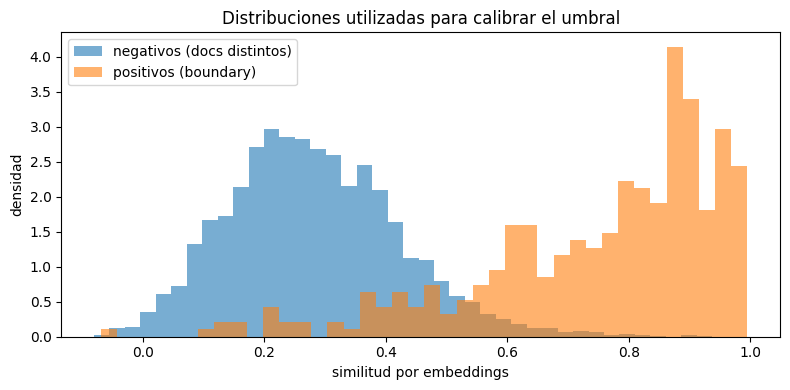

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(sims_neg, bins=40, alpha=0.6, density=True, label="negativos (docs distintos)")
plt.hist(sims_pos, bins=40, alpha=0.6, density=True, label="positivos (boundary)")
plt.xlabel(f"similitud por embeddings")
plt.ylabel("densidad")
plt.title("Distribuciones utilizadas para calibrar el umbral")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Umbral que maximiza el indice de Youden (sensibilidad - tasa de falsos positivos).
grid = np.round(np.arange(0.30, 0.991, 0.01), 3)
tabla_youden = []
for t in grid:
    tpr = float((sims_pos >= t).mean())
    fpr = float((sims_neg >= t).mean())
    tabla_youden.append((t, tpr, fpr, tpr - fpr))

t_opt, tpr_opt, fpr_opt, j_opt = max(tabla_youden, key=lambda r: r[3])
THRESHOLD = float(round(t_opt, 2))

print(f"Umbral calibrado: {THRESHOLD}")
print(f"  recupera el {tpr_opt:.1%} de los aciertos parciales (positivos)")
print(f"  acepta      el {fpr_opt:.1%} de los pares sin relacion (negativos)")
print(f"  indice de Youden = {j_opt:.3f}")
print()
print("Solapamiento entre las dos distribuciones en el umbral elegido:")
print(f"  positivos por debajo del umbral (aciertos parciales que se pierden): "
      f"{(sims_pos < THRESHOLD).mean():.1%}")
print(f"  negativos por encima del umbral (posible credito indebido)        : "
      f"{(sims_neg >= THRESHOLD).mean():.1%}")

Umbral calibrado: 0.55
  recupera el 85.0% de los aciertos parciales (positivos)
  acepta      el 3.7% de los pares sin relacion (negativos)
  indice de Youden = 0.813

Solapamiento entre las dos distribuciones en el umbral elegido:
  positivos por debajo del umbral (aciertos parciales que se pierden): 15.0%
  negativos por encima del umbral (posible credito indebido)        : 3.7%


Algoritmo de asignación

In [29]:
PENALIZACION = -1e6   # costo muy alto para pares por debajo del umbral

def match_hungaro(S, threshold):
    '''Asignacion bipartita optima uno a uno que maximiza la similitud total.'''
    if S.size == 0:
        return []
    S_pen = np.where(S >= threshold, S, PENALIZACION)
    filas, cols = linear_sum_assignment(-S_pen)
    return [(int(i), int(j), float(S[i, j]))
            for i, j in zip(filas, cols) if S[i, j] >= threshold]

MATCHERS = {"hungaro": match_hungaro}
MATCHER_OFICIAL = "hungaro"

Definicion de la metrica semantica

In [30]:
def semantic_prf1_by_doc(true_by_doc, pred_by_doc, sim_name=SIM_OFICIAL,
                         threshold=None, matcher_name=MATCHER_OFICIAL,
                         devolver_detalle=True):
    '''
    Variante semantica de la metrica de coincidencia exacta por documento.
    Agregacion micro por documento original, asignacion uno a uno con umbral.
    '''
    if threshold is None:
        threshold = THRESHOLD
    f = SIM_FUNCS[sim_name]
    matcher = MATCHERS[matcher_name]

    tp = fp = fn = 0
    soft_tp = 0.0
    detalle, no_emparejados = {}, {}

    for doc_id in sorted(set(true_by_doc) | set(pred_by_doc)):
        orig_id = strip_chunk_suffix(doc_id)
        golds = sorted(true_by_doc.get(doc_id, set()))
        preds = sorted(pred_by_doc.get(doc_id, set()))

        if not golds or not preds:
            fp += len(preds)
            fn += len(golds)
            if devolver_detalle:
                no_emparejados[orig_id] = {"fp": preds, "fn": golds}
            continue

        S = f(preds, golds)
        pares = matcher(S, threshold)

        tp += len(pares)
        fp += len(preds) - len(pares)
        fn += len(golds) - len(pares)
        soft_tp += sum(s for _, _, s in pares)

        if devolver_detalle:
            usados_p = {i for i, _, _ in pares}
            usados_g = {j for _, j, _ in pares}
            detalle[orig_id] = [
                {"pred": preds[i], "gold": golds[j], "sim": round(s, 4),
                 "exacto": preds[i] == golds[j]}
                for i, j, s in sorted(pares, key=lambda x: -x[2])
            ]
            no_emparejados[orig_id] = {
                "fp": [p for i, p in enumerate(preds) if i not in usados_p],
                "fn": [g for j, g in enumerate(golds) if j not in usados_g],
            }

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    soft_p  = soft_tp / (tp + fp) if (tp + fp) else 0.0
    soft_r  = soft_tp / (tp + fn) if (tp + fn) else 0.0
    soft_f1 = 2 * soft_p * soft_r / (soft_p + soft_r) if (soft_p + soft_r) else 0.0

    metrics = {"precision": precision, "recall": recall, "f1": f1,
               "tp": tp, "fp": fp, "fn": fn,
               "soft_precision": soft_p, "soft_recall": soft_r, "soft_f1": soft_f1,
               "similitud": sim_name, "umbral": threshold, "asignacion": matcher_name}
    return metrics, detalle, no_emparejados

print("Metrica definida.")

Metrica definida.


In [31]:
metrics_sem, detalle_sem, no_emparejados = semantic_prf1_by_doc(true_by_doc, pred_by_doc)

print("=== Metrica de similitud semantica ===")
print(f"  similitud : {metrics_sem['similitud']}  ({EMB_MODEL_NAME})")
print(f"  asignacion: {metrics_sem['asignacion']} (uno a uno)")
print(f"  umbral    : {metrics_sem['umbral']}")
print()
print(f"  Precision : {metrics_sem['precision']:.4f}")
print(f"  Recall    : {metrics_sem['recall']:.4f}")
print(f"  F1        : {metrics_sem['f1']:.4f}")
print(f"  TP={metrics_sem['tp']}  FP={metrics_sem['fp']}  FN={metrics_sem['fn']}")
print()
print(f"  F1 ponderado por similitud: {metrics_sem['soft_f1']:.4f}")

=== Metrica de similitud semantica ===
  similitud : emb  (sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)
  asignacion: hungaro (uno a uno)
  umbral    : 0.55

  Precision : 0.8787
  Recall    : 0.9089
  F1        : 0.8935
  TP=688  FP=95  FN=69

  F1 ponderado por similitud: 0.8583


In [32]:
# TODO - Poner esta comparación al final
# Comparacion directa entre la metrica de coincidencia exacta y la metrica semantica.
filas = [
    ("Precision", metrics_exact["precision"], metrics_sem["precision"]),
    ("Recall",    metrics_exact["recall"],    metrics_sem["recall"]),
    ("F1",        metrics_exact["f1"],        metrics_sem["f1"]),
]

print("=" * 62)
print(f"{'Metrica':<14}{'Coincid. exacta':>16}{'Similitud sem.':>16}{'Delta':>14}")
print("-" * 62)
for nombre, a, b in filas:
    print(f"{nombre:<14}{a:>16.4f}{b:>16.4f}{b - a:>+14.4f}")
print("-" * 62)
print(f"{'TP':<14}{metrics_exact['tp']:>16}{metrics_sem['tp']:>16}"
      f"{metrics_sem['tp'] - metrics_exact['tp']:>+14}")
print(f"{'FP':<14}{metrics_exact['fp']:>16}{metrics_sem['fp']:>16}"
      f"{metrics_sem['fp'] - metrics_exact['fp']:>+14}")
print(f"{'FN':<14}{metrics_exact['fn']:>16}{metrics_sem['fn']:>16}"
      f"{metrics_sem['fn'] - metrics_exact['fn']:>+14}")
print("=" * 62)
print()
print("Los verdaderos positivos adicionales corresponden a aciertos que la coincidencia")
print("exacta contaba como fallo total:")
print(f"  aciertos recuperados = {metrics_sem['tp'] - metrics_exact['tp']}")

Metrica        Coincid. exacta  Similitud sem.         Delta
--------------------------------------------------------------
Precision               0.7037          0.8787       +0.1750
Recall                  0.7279          0.9089       +0.1810
F1                      0.7156          0.8935       +0.1779
--------------------------------------------------------------
TP                         551             688          +137
FP                         232              95          -137
FN                         206              69          -137

Los verdaderos positivos adicionales corresponden a aciertos que la coincidencia
exacta contaba como fallo total:
  aciertos recuperados = 137


Alcance y limitaciones de la metrica

In [33]:
# 1 - Categorizacion de los aciertos adicionales frente a la coincidencia exacta
def normalizar(s):
    return re.sub(r"[^\w\s]", "", s.lower()).strip()

def categorizar(pred, gold):
    if pred == gold:
        return "exacto"
    if normalizar(pred) == normalizar(gold):
        return "variante de puntuacion/formato"
    if pred in gold or gold in pred:
        return "boundary (uno contiene al otro)"
    if _tokens(pred) & _tokens(gold):
        return "solapamiento parcial de palabras"
    return "sinonimo/parafrasis (sin solapamiento lexico)"

nuevos, por_categoria = [], Counter()
for doc_id, pares in detalle_sem.items():
    for par in pares:
        cat = categorizar(par["pred"], par["gold"])
        por_categoria[cat] += 1
        if not par["exacto"]:
            nuevos.append({"doc_id": doc_id, **par, "categoria": cat})

print(f"Total de aciertos (TP) de la metrica semantica: {metrics_sem['tp']}")
print(f"  de los cuales ya eran aciertos exactos      : {por_categoria['exacto']}")
print(f"  aciertos adicionales aportados por la similitud: {len(nuevos)}")
print()
print("Desglose de los aciertos por tipo de emparejamiento:")
for cat, n in por_categoria.most_common():
    print(f"  {cat:<48}{n:>5}  ({n / metrics_sem['tp']:.1%})")

Total de aciertos (TP) de la metrica semantica: 688
  de los cuales ya eran aciertos exactos      : 542
  aciertos adicionales aportados por la similitud: 146

Desglose de los aciertos por tipo de emparejamiento:
  exacto                                            542  (78.8%)
  boundary (uno contiene al otro)                   115  (16.7%)
  sinonimo/parafrasis (sin solapamiento lexico)      22  (3.2%)
  solapamiento parcial de palabras                    9  (1.3%)


In [34]:
# Muestra de aciertos adicionales, ordenados de mayor a menor similitud
print("Ejemplos de aciertos que la coincidencia exacta contaba como fallo total:")
print()
for caso in sorted(nuevos, key=lambda c: -c["sim"])[:15]:
    print(f"  [{caso['doc_id']:<6}] sim={caso['sim']:.3f}  {caso['categoria']}")
    print(f"           pred: {caso['pred']!r}")
    print(f"           gold: {caso['gold']!r}")

Ejemplos de aciertos que la coincidencia exacta contaba como fallo total:

  [ex_12 ] sim=0.994  boundary (uno contiene al otro)
           pred: 'hipogonadismo con'
           gold: 'hipogonadismo'
  [ex_16 ] sim=0.991  boundary (uno contiene al otro)
           pred: 'enfermedad de crohn con afectación ileal y perianal compleja'
           gold: 'enfermedad de crohn con afectación ileal y perianal'
  [ex_2  ] sim=0.990  boundary (uno contiene al otro)
           pred: 'micrognatismo con'
           gold: 'micrognatismo'
  [ex_9  ] sim=0.989  boundary (uno contiene al otro)
           pred: 'hepatitis isquémica asociada'
           gold: 'hepatitis isquémica'
  [ex_42 ] sim=0.988  boundary (uno contiene al otro)
           pred: 'fístula arterio-cavernosa en la porción proximal del cuerpo cavernoso derecho'
           gold: 'fístula arterio-cavernosa en la porción proximal del cuerpo cavernoso'
  [ex_14 ] sim=0.987  boundary (uno contiene al otro)
           pred: 'insuficiencia cardi

In [35]:
# 2 - Emparejamientos que dependen unicamente del embedding, sin ningun
# solapamiento lexico entre la prediccion y la entidad esperada.
sospechosos = [c for c in nuevos
               if c["categoria"] == "sinonimo/parafrasis (sin solapamiento lexico)"]

print(f"Emparejamientos que dependen unicamente del embedding: {len(sospechosos)} "
      f"({len(sospechosos) / max(metrics_sem['tp'], 1):.1%} del total de aciertos)")
print()
print("Requieren revision manual para determinar cuales son sinonimos reales:")
for caso in sorted(sospechosos, key=lambda c: -c["sim"])[:20]:
    print(f"  [{caso['doc_id']:<6}] sim={caso['sim']:.3f}  "
          f"pred={caso['pred']!r}  gold={caso['gold']!r}")

Emparejamientos que dependen unicamente del embedding: 22 (3.2% del total de aciertos)

Requieren revision manual para determinar cuales son sinonimos reales:
  [ex_11 ] sim=0.925  pred='lesión'  gold='lesiones'
  [ex_2  ] sim=0.826  pred='dilataciones ureterales bilaterales'  gold='uretero-hidronefrosis bilateral'
  [ex_18 ] sim=0.756  pred='tumor'  gold='carcinoma embrionario'
  [ex_35 ] sim=0.751  pred='neoformaciones'  gold='vejiga de poca capacidad con neoformación'
  [ex_30 ] sim=0.748  pred='vvz'  gold='heces melénicas'
  [ex_21 ] sim=0.723  pred='arritmias'  gold='vía anómala'
  [ex_36 ] sim=0.692  pred='infestación por pediculosis'  gold='enfermedades infecciosas'
  [ex_0  ] sim=0.677  pred='ganglio linfático'  gold='orificio fistuloso'
  [ex_23 ] sim=0.667  pred='traumatismo frontal'  gold='lesión directa del no'
  [ex_18 ] sim=0.662  pred='seminoma'  gold='testículo atrófico'
  [ex_10 ] sim=0.642  pred='globo vesical'  gold='letàlides'
  [ex_41 ] sim=0.611  pred='recidiva lo

In [36]:
# 3 - Ambiguedad dentro del propio conjunto de referencia: pares de entidades
# esperadas del mismo documento con similitud alta entre si.
pares_gold_ambiguos, total_pares_gold = 0, 0
ejemplos_ambiguos = []

for doc_id, golds in true_by_doc.items():
    golds = sorted(golds)
    if len(golds) < 2:
        continue
    S_gg = sim_fn(golds, golds)
    for i in range(len(golds)):
        for j in range(i + 1, len(golds)):
            total_pares_gold += 1
            if S_gg[i, j] >= THRESHOLD:
                pares_gold_ambiguos += 1
                ejemplos_ambiguos.append((doc_id, golds[i], golds[j], float(S_gg[i, j])))

frac_ambigua = pares_gold_ambiguos / total_pares_gold if total_pares_gold else 0.0
print(f"Pares de entidades esperadas del mismo documento con similitud >= umbral: "
      f"{pares_gold_ambiguos} / {total_pares_gold}  ({frac_ambigua:.2%})")
print()
print("Ejemplos de entidades esperadas mutuamente indistinguibles para esta metrica:")
for doc_id, a, b, s in sorted(ejemplos_ambiguos, key=lambda x: -x[3])[:12]:
    print(f"  [{doc_id:<6}] sim={s:.3f}  {a!r}  <->  {b!r}")

Pares de entidades esperadas del mismo documento con similitud >= umbral: 537 / 5434  (9.88%)

Ejemplos de entidades esperadas mutuamente indistinguibles para esta metrica:
  [ex_27 ] sim=0.990  'gammapatía monoclonal con igm'  <->  'gammapatía monoclonal igm'
  [ex_20 ] sim=0.990  'insuficiencia renal'  <->  'insuficiencia renal aguda'
  [ex_11 ] sim=0.974  'carcinoma de colon'  <->  'carcinoma de colon descendente'
  [ex_9  ] sim=0.973  'hepatitis aguda'  <->  'hepatitis isquémica'
  [ex_6  ] sim=0.971  'liposarcoma bien diferenciado'  <->  'liposarcoma desdiferenciado'
  [ex_45 ] sim=0.970  'pancreatitis aguda'  <->  'pancreatitis crónica'
  [ex_6  ] sim=0.961  'liposarcoma bien diferenciado'  <->  'liposarcoma bien diferenciado (lipoma-like'
  [ex_45 ] sim=0.960  'pancreatitis aguda'  <->  'pancreatitis aguda moderada-severa'
  [ex_40 ] sim=0.944  'carcinoma de células acinares'  <->  'carcinoma de células acinares de bajo grado'
  [ex_1  ] sim=0.943  'hipertensión'  <->  'hiperten

###  Exportar resultados

In [37]:
resultado_dimension1b = {
    "dimension": "metrica_clasica_matching_semantico",
    "modelo": "PlanTL-GOB-ES/roberta-base-biomedical-clinical-es",
    "predicciones_origen": str(DIM1_PATH),
    "gold_set": str(GOLD_SET_PATH),
    "n_ejemplos_evaluados": len(true_by_doc),

    "configuracion": {
        "modelo_embeddings": EMB_MODEL_NAME,
        "funcion_similitud": SIM_OFICIAL,
        "algoritmo_asignacion": MATCHER_OFICIAL,
        "restriccion": "uno a uno",
        "umbral": THRESHOLD,
        "criterio_umbral": "indice de Youden sobre positivos boundary vs negativos cross-document",
        "umbral_tpr_positivos": round(float((sims_pos >= THRESHOLD).mean()), 4),
        "umbral_fpr_negativos": round(float((sims_neg >= THRESHOLD).mean()), 4),
    },

    "metrics": {k: v for k, v in metrics_sem.items()},
    "metrics_exact_match_referencia": metrics_exact,

    "aciertos_por_categoria": dict(por_categoria),
    "aciertos_nuevos": nuevos,
    "emparejamientos_solo_embedding": sospechosos,
    "ambiguedad_gold": {
        "pares_ambiguos": pares_gold_ambiguos,
        "pares_totales": total_pares_gold,
        "fraccion": round(frac_ambigua, 4),
        "ejemplos": [{"doc_id": d, "gold_a": a, "gold_b": b, "sim": round(s, 4)}
                     for d, a, b, s in sorted(ejemplos_ambiguos, key=lambda x: -x[3])[:50]],
    },
    "detalle_emparejamientos": detalle_sem,
    "no_emparejados": no_emparejados,
}

with open(DIM1B_PATH, "w", encoding="utf-8") as f:
    json.dump(resultado_dimension1b, f, indent=2, ensure_ascii=False)

print("Guardado en:", DIM1B_PATH)
print()
print("Resumen final:")
print(f"  Coincidencia exacta : F1 = {metrics_exact['f1']:.4f}")
print(f"  Similitud semantica : F1 = {metrics_sem['f1']:.4f}  "
      f"(umbral={THRESHOLD}, {"Similitud por embbedings"}, {MATCHER_OFICIAL} uno a uno)")
print(f"  Aciertos recuperados: {metrics_sem['tp'] - metrics_exact['tp']}")

Guardado en: /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/outputs/resultado_dimension1b.json

Resumen final:
  Coincidencia exacta : F1 = 0.7156
  Similitud semantica : F1 = 0.8935  (umbral=0.55, Similitud por embbedings, hungaro uno a uno)
  Aciertos recuperados: 137


## Sección 7 - LLM as a judge

In [ ]:
# Juez LLM
GROQ_API_KEY = ""   # pegar la API key aquí (gratis en https://console.groq.com/keys)

# Modelo preferido para el juez
JUDGE_MODEL  = "openai/gpt-oss-120b"

JUDGE_TEMPERATURE   = 0.0   # determinístico
JUDGE_MAX_TOKENS    = 1500  # suficiente para modelos con CoT/razonamiento en ejemplos largos

# Modelos de respaldo por orden de preferencia para evaluación LLM
CANDIDATE_JUDGE_MODELS = [
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "openai/gpt-oss-120b",
    "llama3-70b-8192",
    "llama-3.2-11b-vision-preview",
    "qwen/qwen3.6-27b",
    "deepseek-r1-distill-llama-70b",
    "mixtral-8x7b-32768",
    "gemma2-9b-it",
    "llama3-8b-8192",
]

In [41]:
import os
from groq import Groq

api_key = GROQ_API_KEY or os.environ.get("GROQ_API_KEY", "")
if not api_key:
    raise ValueError(
        "No se encontró la API key de Groq. "
        "Obtén una gratis en https://console.groq.com/keys y pégala en GROQ_API_KEY."
    )

groq_client = Groq(api_key=api_key)

def test_model_ping(model_name: str) -> bool:
    try:
        groq_client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": "hola"}],
            max_tokens=10,
        )
        return True
    except Exception:
        return False

# Si el modelo no está disponible mostrar mensaje de error
if not test_model_ping(JUDGE_MODEL):
    raise RuntimeError(
        f"El modelo juez '{JUDGE_MODEL}' no esta disponible en Groq (probablemente deprecado).\n"
        f"Revisar https://console.groq.com/docs/deprecations y actualizar JUDGE_MODEL manualmente.\n"
        f"NO se aplica fallback automatico para preservar reproducibilidad entre ejecuciones."
    )
else:
  chosen_model = JUDGE_MODEL
  print(f"\n[OK] Modelo juez configurado '{JUDGE_MODEL}' verificado exitosamente.")


# Comprobar si el modelo soporta response_format={'type': 'json_object'}
SUPPORTS_JSON_MODE = True
try:
    groq_client.chat.completions.create(
        model=JUDGE_MODEL,
        messages=[
            {"role": "system", "content": "Responde solo JSON."},
            {"role": "user", "content": "Genera {\"ping\": \"pong\"}"},
        ],
        max_tokens=25,
        response_format={"type": "json_object"},
    )
    print("  Soporte de JSON mode nativo (response_format): SI")
except Exception:
    SUPPORTS_JSON_MODE = False
    print("  Soporte de JSON mode nativo (response_format): NO (se usará parseo robusto por regex)")

print(f"\nJuez LLM listo para evaluación: {JUDGE_MODEL} (Groq API)")



[OK] Modelo juez configurado 'openai/gpt-oss-120b' verificado exitosamente.
  Soporte de JSON mode nativo (response_format): NO (se usará parseo robusto por regex)

Juez LLM listo para evaluación: openai/gpt-oss-120b (Groq API)


Poner datos en el formato esperado para esta dimensión

In [46]:
with open(DIM1_PATH, "r", encoding="utf-8") as f:
    dim1 = json.load(f)

true_by_doc_dim1 = dim1["true_by_doc"]  # {doc_id: [entidades gold...]}
pred_by_doc_dim1 = dim1["pred_by_doc"]  # {doc_id: [entidades predichas...]}

rich_examples = []
for doc_id in sorted(true_by_doc_dim1):
    gold = sorted(true_by_doc_dim1[doc_id])
    pred = sorted(pred_by_doc_dim1.get(doc_id, []))
    rich_examples.append({
        "doc_id": doc_id,
        "n_gold": len(gold),
        "gold": gold,
        "pred": pred,
    })

print(f"Ejemplos cargados desde Dimension 1: {len(rich_examples)}")
print(f"Mismo gold set que exact-match y similitud semantica -- sin asimetria de subset.")

for doc in rich_examples[:3]:
    print(f"\ndoc_id: {doc['doc_id']} | n_gold: {doc['n_gold']}")
    print(f"  Gold: {doc['gold']}")
    print(f"  Pred: {doc['pred']}")

Ejemplos cargados desde Dimension 1: 59
Mismo gold set que exact-match y similitud semantica -- sin asimetria de subset.

doc_id: ex_0 | n_gold: 28
  Gold: ['adenopatías', 'adenopatías bilaterales en las cadenas iliacas interna y externa y en las cadenas inguinales', 'adenopatías bilaterales ilíacas e inguinales', 'afectación de las cadenas ganglionares', 'brucelosis', 'carcinoma verrugoso de buscke-lowenstein', 'condiloma acuminado gigante de buschke-lowenstein', 'herida de la incisión de linfadenectomía', 'hipogonadismo hipergonadotrópico', 'infiltraba igualmente los tejidos pubianos, el escroto', 'infiltración de la grasa del tejido celular subcutáneo de la pared interna de los muslos ni de la grasa del periné', 'infiltración metastásica', 'infiltrar también la fascia del músculo aductor', 'lesiones óseas en las ramas isquio-ileo-pubianas', 'lesión', 'lesión penoescrotal', 'lesión tumoral', 'linfogranuloma venéreo', 'lúes', 'masa tumoral', 'metástasis de carcinoma', 'metástasis tumo

RUBRICA del juez

Evalúa en 4 dimensiones (1–5 cada una):

| Dimensión | Descripción |
|---|---|
| **Completitud** | ¿Capturó la mayoría de las enfermedades mencionadas? |
| **Exactitud de boundary** | ¿Los nombres coinciden con el gold (o casi)? |
| **Relevancia clínica** | ¿Las predicciones son términos clínicamente válidos? |
| **Ausencia de ruido** | ¿Evitó marcar términos que NO son enfermedades? |

Score final = promedio de las 4 dimensiones.


In [47]:
RUBRICA_SYSTEM = (
    "Eres un médico especialista en terminología médica y anotación de entidades clínicas. "
    "Tu tarea es evaluar la calidad de las entidades clínicas predichas por un sistema de NER, "
    "comparando sus predicciones con una lista gold. "
    "Evalúa SOLO el contenido. No sabes qué modelo generó las predicciones."
)

RUBRICA_TEMPLATE = """
# Evaluación de NER clínico — RUBRICA

## Referencia (gold standard)
Enfermedades correctas: {gold_str}

## Predicción del sistema
Enfermedades detectadas: {pred_str}

## Instrucciones
Evalúa en cada dimensión del 1 al 5:

1. **Completitud** (¿capturó la mayoría de las enfermedades gold?):
   5=todas/casi todas | 3=la mitad | 1=prácticamente nada

2. **Exactitud de boundary** (¿los nombres coinciden con el gold?):
   5=coincidencia exacta o diferencia mínima | 3=algunos coinciden, otros truncados | 1=no se parecen

3. **Relevancia clínica** (¿las predicciones son términos de enfermedades válidos?):
   5=todas válidas | 3=mezcla | 1=mayoría inválidas

4. **Ausencia de ruido** (¿evitó marcar términos que NO son enfermedades?):
   5=sin FP notables | 3=algunos FP | 1=demasiados FP

## Respuesta
Responde ÚNICAMENTE en JSON válido con el siguiente formato:
```json
{{
  "completitud": <1-5>,
  "exactitud_boundary": <1-5>,
  "relevancia_clinica": <1-5>,
  "ausencia_ruido": <1-5>,
  "justificacion": "<una oración breve>"
}}
```
"""


def build_judge_prompt(gold: list, pred: list, order: str = "normal") -> str:
    gold_str = ", ".join(gold) if gold else "(ninguna)"
    pred_str = ", ".join(pred) if pred else "(ninguna)"
    if order == "inverted":
        return RUBRICA_TEMPLATE.format(gold_str=pred_str, pred_str=gold_str)
    return RUBRICA_TEMPLATE.format(gold_str=gold_str, pred_str=pred_str)


def parse_judge_response(text: str) -> dict:
    # 1. Intentar parsear bloque JSON completo
    for pattern in [r"```(?:json)?\s*({[\s\S]*?})\s*```", r"({[\s\S]*?})"]:
        m = re.search(pattern, text)
        if m:
            try:
                return json.loads(m.group(1))
            except Exception:
                pass
    try:
        return json.loads(text.strip())
    except Exception:
        pass

    # 2. Fallback resiliente: extracción directa por regex de cada dimensión (evita fallos por CoT o truncamiento)
    result = {}
    for key in ["completitud", "exactitud_boundary", "relevancia_clinica", "ausencia_ruido"]:
        val_m = re.search(rf'"{key}"\s*:\s*([1-5])', text, re.IGNORECASE)
        result[key] = int(val_m.group(1)) if val_m else None

    just_m = re.search(r'"justificacion"\s*:\s*"([^"\n]+)', text, re.IGNORECASE)
    result["justificacion"] = just_m.group(1) if just_m else (text[-200:].strip() if text else "Sin texto")
    return result


def compute_score(d: dict) -> float:
    vals = [d.get(k) for k in ["completitud","exactitud_boundary",
                                "relevancia_clinica","ausencia_ruido"]
            if d.get(k) is not None]
    return float(np.mean(vals)) if vals else None


def call_judge(gold: list, pred: list, order: str = "normal",
               retry: int = 5, sleep_s: float = 1.0) -> dict:
    """
    Llama al juez LLM vía Groq con reintentos y tolerancia a fallos.
    Si el modelo no soporta response_format={'type': 'json_object'}, hace fallback
    automático a modo texto estándar y parsea la respuesta con regex.
    Maneja también esperas exponenciales ante rate limits (429).
    """
    prompt = build_judge_prompt(gold, pred, order=order)
    use_json_mode = globals().get("SUPPORTS_JSON_MODE", True)

    for attempt in range(retry):
        try:
            kwargs = {
                "model": JUDGE_MODEL,
                "messages": [
                    {"role": "system", "content": RUBRICA_SYSTEM},
                    {"role": "user", "content": prompt},
                ],
                "temperature": JUDGE_TEMPERATURE,
                "max_tokens": JUDGE_MAX_TOKENS,
            }
            if use_json_mode:
                kwargs["response_format"] = {"type": "json_object"}

            response = groq_client.chat.completions.create(**kwargs)
            time.sleep(sleep_s)
            content = response.choices[0].message.content
            parsed = parse_judge_response(content)

            # Si se obtuvo al menos una dimensión numérica válida, el llamado fue exitoso
            if any(parsed.get(k) is not None for k in ["completitud", "exactitud_boundary", "relevancia_clinica", "ausencia_ruido"]):
                return parsed

            # Si no parseó pero usábamos json_mode, reintentar sin json_mode
            if attempt == 0 and use_json_mode:
                use_json_mode = False
                continue

            return parsed
        except Exception as e:
            err_str = str(e)
            if "response_format" in err_str or "json_object" in err_str:
                use_json_mode = False

            is_rate_limit = "429" in err_str or "rate_limit" in err_str.lower()
            base_wait = 5 if is_rate_limit else 2
            wait_time = base_wait * (attempt + 1)
            print(f"    [Reintento {attempt+1}/{retry}] {e} -> esperando {wait_time}s...")
            time.sleep(wait_time)

    return {"completitud": None, "exactitud_boundary": None,
            "relevancia_clinica": None, "ausencia_ruido": None,
            "justificacion": "JUDGE_CALL_FAILED"}


test_res = call_judge(["asma crónica"], ["asma"])
print("Test call_judge verificado:", test_res)


Test call_judge verificado: {'completitud': 3, 'exactitud_boundary': 3, 'relevancia_clinica': 5, 'ausencia_ruido': 5, 'justificacion': "Capturó 'asma' correctamente pero omitió el modificador 'crónica', sin errores adicionales."}


Mitigación del sesgo de posición



In [ ]:
print(f"Corriendo juez (normal + invertido) sobre {len(rich_examples)} rich examples...")
print(f"Total llamadas al juez: {len(rich_examples) * 2}\n")

position_results = []

for i, doc in enumerate(rich_examples):
    print(f"  [{i+1}/{len(rich_examples)}] {doc['doc_id']} | n_gold={doc['n_gold']} | n_pred={len(doc['pred'])}")

    result_normal    = call_judge(doc["gold"], doc["pred"], order="normal")
    score_normal     = compute_score(result_normal)

    result_inverted  = call_judge(doc["gold"], doc["pred"], order="inverted")
    score_inverted   = compute_score(result_inverted)

    delta = abs(score_normal - score_inverted) if (score_normal is not None and score_inverted is not None) else None
    valid_scores = [s for s in [score_normal, score_inverted] if s is not None]
    score_mitigado = float(np.mean(valid_scores)) if valid_scores else None

    s_norm_str = f"{score_normal:.2f}" if score_normal is not None else "FAIL"
    s_inv_str  = f"{score_inverted:.2f}" if score_inverted is not None else "FAIL"
    s_mit_str  = f"{score_mitigado:.2f}" if score_mitigado is not None else "FAIL"
    print(f"      Score normal: {s_norm_str} | Score invertido: {s_inv_str} | Mitigado: {s_mit_str}")

    position_results.append({
        "doc_id"         : doc["doc_id"],
        "n_gold"         : doc["n_gold"],
        "n_pred"         : len(doc["pred"]),
        "gold"           : doc["gold"],
        "pred"           : doc["pred"],
        "score_normal"   : score_normal,
        "score_inverted" : score_inverted,
        "delta_posicion" : delta,
        "score_mitigado" : score_mitigado,
        "result_normal"  : result_normal,
        "result_inverted": result_inverted,
    })

print("\nListo.")


In [49]:
df_pos = pd.DataFrame(position_results)
deltas = df_pos["delta_posicion"].dropna()

print("=" * 55)
print("ANÁLISIS — SESGO DE POSICIÓN")
print("=" * 55)
print(f"  Ejemplos evaluados          : {len(df_pos)}")
print(f"  Delta medio  |normal-inv|   : {deltas.mean():.3f}")
print(f"  Delta máximo                : {deltas.max():.3f}")
print(f"  Delta mediana               : {deltas.median():.3f}")
print(f"  % ejemplos con delta > 1    : {(deltas > 1).mean()*100:.1f}%")
print()

if deltas.mean() < 0.5:
    verdict = "ESTABLE respecto a posición (delta medio < 0.5). Mitigación es una precaución razonable."
elif deltas.mean() < 1.0:
    verdict = "SESGO MODERADO de posición (delta 0.5–1.0). Mitigación reduce el efecto."
else:
    verdict = "SESGO FUERTE de posición (delta > 1.0). Considerar cambiar el prompt."
print(f"Conclusión: {verdict}")

print("\nTop 5 con mayor delta:")
display(df_pos[["doc_id", "score_normal", "score_inverted", "delta_posicion"]]
        .sort_values("delta_posicion", ascending=False).head(5))


ANÁLISIS — SESGO DE POSICIÓN
  Ejemplos evaluados          : 59
  Delta medio  |normal-inv|   : 0.461
  Delta máximo                : 1.250
  Delta mediana               : 0.500
  % ejemplos con delta > 1    : 6.9%

Conclusión: ESTABLE respecto a posición (delta medio < 0.5). Mitigación es una precaución razonable.

Top 5 con mayor delta:


,doc_id,score_normal,score_inverted,delta_posicion
8,ex_16,2.75,4.0,1.25
12,ex_2,3.25,4.5,1.25
14,ex_21,3.25,4.5,1.25
17,ex_24,3.25,4.5,1.25
13,ex_20,3.00,4.0,1.00


Nota: En el notebook base se demuestra que no se necesita corrección por sesgos de longitud ni por autopreferencia.

In [ ]:
def compute_exact_f1_doc(gold: list, pred: list) -> dict:
    """F1 exact-match para un documento (para triangular con la métrica de Luis)."""
    g, p = set(gold), set(pred)
    tp   = len(g & p)
    fp   = len(p - g)
    fn   = len(g - p)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) else 0.0
    return {"precision": prec, "recall": rec, "f1": f1}


scorecard_rows = []
for row in position_results:
    exact = compute_exact_f1_doc(row["gold"], row["pred"])
    scorecard_rows.append({
        "doc_id"          : row["doc_id"],
        "n_gold_entities" : row["n_gold"],
        "n_pred_entities" : row["n_pred"],
        "score_juez"      : row["score_mitigado"],
        "delta_posicion"  : row["delta_posicion"],
        "f1_exacto"       : exact["f1"],
        "precision_exacta": exact["precision"],
        "recall_exacto"   : exact["recall"],
        "score_semantico" : None,   # placeholder — tarea de Pau
        "gold"            : row["gold"],
        "pred"            : row["pred"],
        "justificacion"   : row["result_normal"].get("justificacion", ""),
    })

df_sc = pd.DataFrame(scorecard_rows)

print("=" * 55)
print("SCORECARD — Rich Examples")
print("=" * 55)
print(f"  Docs evaluados           : {len(df_sc)}")
print(f"  Score juez (mitigado)    : {df_sc['score_juez'].mean():.3f} ± {df_sc['score_juez'].std():.3f}")
print(f"  F1 exacto (mismo subset) : {df_sc['f1_exacto'].mean():.3f} ± {df_sc['f1_exacto'].std():.3f}")
print()
display(df_sc[["doc_id", "n_gold_entities", "n_pred_entities",
               "score_juez", "delta_posicion",
               "f1_exacto", "precision_exacta", "recall_exacto"]])


Interpretación — ¿Qué revela el juez que el F1 exacto no capta?

| Patrón | F1 exacto | Score juez | Interpretación |
|--------|-----------|-----------|----------------|
| **A** | ≈ 0 | ≥ 3.5 | Entendió la entidad pero con **boundary distinto** — error de span, no de comprensión. |
| **B** | > 0.3 | ≤ 2.5 | Acertó la string exacta pero el output **no es clínicamente satisfactorio**. |
| **C** | ≈ 0 | ≤ 2.0 | Fallo completo. |
| **D** | ≥ 0.7 | ≥ 4.0 | Funcionamiento correcto — referencia positiva. |
| **E** | resto | resto | Caso mixto. |


In [51]:
def classify_pattern(row):
    s, f = row["score_juez"], row["f1_exacto"]
    if s is None or f is None: return "? — datos faltantes"
    if f < 0.1 and s >= 3.5:   return "A — boundary error (comprensión OK, span malo)"
    if f > 0.3 and s <= 2.5:   return "B — string OK, calidad clínica baja"
    if f < 0.1 and s <= 2.0:   return "C — fallo completo"
    if f >= 0.7 and s >= 4.0:  return "D — referencia positiva"
    return "E — caso mixto"


df_sc["patron"] = df_sc.apply(classify_pattern, axis=1)
print("Distribución de patrones:")
print(df_sc["patron"].value_counts().to_string())

for patron_key, label in [("A", "Boundary error, comprensión OK"),
                           ("B", "String OK, calidad clínica baja")]:
    sub = df_sc[df_sc["patron"].str.startswith(patron_key)]
    print(f"\n--- Patrón {patron_key} ({len(sub)} docs) — {label} ---")
    for _, r in sub.iterrows():
        print(f"  doc: {r['doc_id'][:45]:45s} | F1={r['f1_exacto']:.2f} | Juez={r['score_juez']:.2f}")
        print(f"    Gold: {r['gold']}")
        print(f"    Pred: {r['pred']}")


Distribución de patrones:
patron
E — caso mixto                         34
D — referencia positiva                24
B — string OK, calidad clínica baja     1

--- Patrón A (0 docs) — Boundary error, comprensión OK ---

--- Patrón B (1 docs) — String OK, calidad clínica baja ---
  doc: ex_28                                         | F1=0.50 | Juez=2.50
    Gold: ['cuerpo extraño de densidad metálica alojado en el canal raquídeo a nivel de c2', 'disparo por arma de fuego en la orofaringe', 'excoriación en la base lingual', 'hematoma retrofaríngeo', 'herida en forma de semiluna con ligera pérdida de sustancia', 'herida por arma de fuego de proyectil único, que penetra por un orificio natural, concretamente el orificio nasal', 'lesionando la médula', 'lesiones', 'médula, seccionándola parcialmente', 'orifico nasal derecho, una pequeña excoriación de forma de semilunar con una discreta pérdida de sustancia', 'parada cardiorrespiratoria', 'perfora el paladar duro', 'proyectil de arma de fue

Mitigación del sesgo de longitud


In [61]:
LENGTH_BIAS_PAIRS = [
    # Tipo A — correcta corta vs. incorrecta larga
    {
        "tipo": "A", "descripcion": "Correcta corta vs. Incorrecta larga",
        "gold": ["neumonía", "sepsis"],
        "pred_correcta" : ["neumonía"],
        "pred_incorrecta": ["hiperglucemia", "dislipidemia", "hipotiroidismo",
                             "artritis reumatoide", "fibromialgia",
                             "esclerosis múltiple", "enfermedad de crohn", "psoriasis"],
    },
    {
        "tipo": "A", "descripcion": "Correcta corta vs. Incorrecta larga",
        "gold": ["infarto agudo de miocardio", "insuficiencia cardiaca", "fibrilación auricular"],
        "pred_correcta" : ["infarto agudo de miocardio"],
        "pred_incorrecta": ["diabetes mellitus tipo 2", "hipertensión arterial",
                             "anemia ferropénica", "neuropatía diabética",
                             "retinopatía diabética", "enfermedad renal crónica", "osteoporosis"],
    },
    # Tipo B — correcta larga vs. incorrecta corta
    {
        "tipo": "B", "descripcion": "Correcta larga vs. Incorrecta corta",
        "gold": ["neumonía", "sepsis", "insuficiencia respiratoria aguda"],
        "pred_correcta" : ["neumonía", "sepsis", "insuficiencia respiratoria aguda"],
        "pred_incorrecta": ["fibromialgia"],
    },
    {
        "tipo": "B", "descripcion": "Correcta larga vs. Incorrecta corta",
        "gold": ["carcinoma ductal infiltrante", "metástasis hepática",
                  "anemia", "trombocitopenia", "neutropenia febril"],
        "pred_correcta" : ["carcinoma ductal infiltrante", "metástasis hepática",
                             "anemia", "trombocitopenia"],
        "pred_incorrecta": ["psoriasis"],
    },
    # Tipo A especial — gold vacío
    {
        "tipo": "A", "descripcion": "Correcta vacía vs. Incorrecta larga (FP puros)",
        "gold": [],
        "pred_correcta" : [],
        "pred_incorrecta": ["artritis", "hipertensión", "diabetes",
                              "anemia", "fibromialgia", "neuropatía"],
    },
]
print(f"Pares preparados: {len(LENGTH_BIAS_PAIRS)}")
for p in LENGTH_BIAS_PAIRS:
    print(f"  Tipo {p['tipo']}: n_correcta={len(p['pred_correcta'])}, n_incorrecta={len(p['pred_incorrecta'])}")


Pares preparados: 5
  Tipo A: n_correcta=1, n_incorrecta=8
  Tipo A: n_correcta=1, n_incorrecta=7
  Tipo B: n_correcta=3, n_incorrecta=1
  Tipo B: n_correcta=4, n_incorrecta=1
  Tipo A: n_correcta=0, n_incorrecta=6


In [62]:
print("Corriendo juez sobre pares de longitud...")
length_results = []

for i, pair in enumerate(LENGTH_BIAS_PAIRS):
    print(f"  [{i+1}/{len(LENGTH_BIAS_PAIRS)}] Tipo {pair['tipo']} — {pair['descripcion']}")
    r_cor = call_judge(pair["gold"], pair["pred_correcta"],  order="normal")
    r_inc = call_judge(pair["gold"], pair["pred_incorrecta"], order="normal")
    sc, si = compute_score(r_cor), compute_score(r_inc)
    length_results.append({
        "tipo"              : pair["tipo"],
        "descripcion"       : pair["descripcion"],
        "n_correcta"        : len(pair["pred_correcta"]),
        "n_incorrecta"      : len(pair["pred_incorrecta"]),
        "score_correcta"    : sc,
        "score_incorrecta"  : si,
        "juez_premia_calidad": (sc > si) if (sc is not None and si is not None) else None,
        "justif_correcta"   : r_cor.get("justificacion", ""),
        "justif_incorrecta" : r_inc.get("justificacion", ""),
    })

print("\nListo.")


Corriendo juez sobre pares de longitud...
  [1/5] Tipo A — Correcta corta vs. Incorrecta larga
  [2/5] Tipo A — Correcta corta vs. Incorrecta larga
  [3/5] Tipo B — Correcta larga vs. Incorrecta corta
  [4/5] Tipo B — Correcta larga vs. Incorrecta corta
  [5/5] Tipo A — Correcta vacía vs. Incorrecta larga (FP puros)

Listo.


In [63]:
df_len  = pd.DataFrame(length_results)
n_ok    = df_len["juez_premia_calidad"].sum()
n_total = df_len["juez_premia_calidad"].notna().sum()

print("=" * 55)
print("ANÁLISIS — SESGO DE LONGITUD")
print("=" * 55)
print(f"  Pares evaluados: {n_total}")
print(f"  El juez premió calidad sobre longitud: {n_ok}/{n_total} ({n_ok/n_total*100:.0f}%)")
print()

if n_ok / n_total >= 0.8:
    print("El juez NO muestra sesgo de longitud relevante.")
elif n_ok / n_total >= 0.6:
    print("Sesgo LEVE de longitud — en algunos casos premia extensión.")
else:
    print("Sesgo FUERTE de longitud — agregar instrucción explícita al prompt.")

print()
display(df_len[["tipo", "descripcion", "n_correcta", "n_incorrecta",
               "score_correcta", "score_incorrecta", "juez_premia_calidad"]])


ANÁLISIS — SESGO DE LONGITUD
  Pares evaluados: 5
  El juez premió calidad sobre longitud: 5/5 (100%)

El juez NO muestra sesgo de longitud relevante.



,tipo,descripcion,n_correcta,n_incorrecta,score_correcta,score_incorrecta,juez_premia_calidad
0,A,Correcta corta vs. Incorrecta larga,1,8,4.50,3.0,True
1,A,Correcta corta vs. Incorrecta larga,1,7,4.25,3.0,True
2,B,Correcta larga vs. Incorrecta corta,3,1,5.00,3.0,True
3,B,Correcta larga vs. Incorrecta corta,4,1,4.75,3.0,True
4,A,Correcta vacía vs. Incorrecta larga (FP puros),0,6,5.00,4.0,True


Sesgo de auto-preferencia


In [64]:
sample_prompt = build_judge_prompt(["neumonía", "sepsis"], ["neumonía"])
forbidden     = ["roberta", "bert", "mt5", "llama", "gpt", "gemini", "plantl", "biomedical", "clinical"]
found = [n for n in forbidden if n.lower() in sample_prompt.lower()]

if not found:
    print("El prompt NO menciona ningún modelo — output completamente anonimizado.")
else:
    print(f"ATENCIÓN: el prompt menciona {found} — revisar RUBRICA_TEMPLATE.")

print()
print("Resumen de mitigaciones de auto-preferencia:")
print("  1. Output anonimizado (sin nombres de modelo en el prompt): OK")
print("  2. Formato estandarizado (lista -> str uniforme): OK")
print(f"  3. Familia cruzada independiente (Juez: {JUDGE_MODEL} vs. RoBERTa): OK")


El prompt NO menciona ningún modelo — output completamente anonimizado.

Resumen de mitigaciones de auto-preferencia:
  1. Output anonimizado (sin nombres de modelo en el prompt): OK
  2. Formato estandarizado (lista -> str uniforme): OK
  3. Familia cruzada independiente (Juez: openai/gpt-oss-120b vs. RoBERTa): OK


###  Exportar resultados

In [65]:
resultado_dimension3 = {
    "dimension": "llm_as_judge",
    "rol": "agustin",

    "modelo": "PlanTL-GOB-ES/roberta-base-biomedical-clinical-es",
    "predicciones_origen": str(DIM1_PATH),
    "gold_set": str(GOLD_SET_PATH),
    "n_ejemplos_evaluados": len(true_by_doc),

    "modelo_juez": JUDGE_MODEL,
    "judge_provider": "Groq",

    "predicciones_origen": str(DIM1_PATH),

    "n_ejemplos_evaluados": len(rich_examples),
    "seed": SEED,

    "metrics": {
        "score_juez_mean": float(df_sc["score_juez"].mean()),
        "score_juez_std": float(df_sc["score_juez"].std()),
        "f1_exacto_mean": float(df_sc["f1_exacto"].mean()),
    },

    "sesgo_posicion": {
        "delta_mean": float(deltas.mean()),
        "delta_max": float(deltas.max()),
        "delta_median": float(deltas.median()),
        "pct_delta_mayor_a_1": float((deltas > 1).mean()),
        "mitigacion": "promedio de score_normal y score_inverted",
    },
    "sesgo_longitud": {
        "pares_evaluados": int(n_total),
        "pares_calidad_gana": int(n_ok),
        "pct_calidad_gana": float(n_ok / n_total),
        "mitigacion": "pares de validacion con asimetria de longitud controlada",
    },
    "sesgo_autopreferencia": {
        "output_anonimizado": True,
        "formato_estandarizado": True,
        "familia_cruzada": True,
        "test_cross_family_disponible": False,
        "nota": "No se puede cuantificar sin un segundo juez de otra familia distinta",
    },

    "distribucion_patrones": df_sc["patron"].value_counts().to_dict(),

    # Sets a listas ordenadas para serializacion deterministica entre ejecuciones,
    # igual que en Dimension 1 -- pero aca cada entrada trae ademas el score del juez.
    "resultados_por_doc": {
        row["doc_id"]: {
            "gold": sorted(row["gold"]),
            "pred": sorted(row["pred"]),
            "score_juez": row["score_juez"],
            "delta_posicion": row["delta_posicion"],
            "f1_exacto": row["f1_exacto"],
            "patron": row["patron"],
        }
        for row in df_sc.to_dict(orient="records")
    },
}

DIM3_PATH = OUTPUT_DIR / "resultado_dimension3.json"
with open(DIM3_PATH, "w", encoding="utf-8") as f:
    json.dump(resultado_dimension3, f, indent=2, ensure_ascii=False)

print(f"Guardado en: {DIM3_PATH}")

Guardado en: /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/outputs/resultado_dimension3.json


## Sección 8 - Scorecard final

In [67]:
# ============================================================
# SCORECARD INTEGRADOR -- Isa
# Junta las 3 dimensiones (exact-match, similitud semantica, LLM-as-judge)
# en un solo scorecard legible, con diagnostico de debilidad por documento.
# ============================================================

import json
from collections import Counter
from pathlib import Path

# --- 1. Cargar los 3 resultados ---------------------------------------------

for path, nombre in [(DIM1_PATH, "exact-match"),
                      (DIM1B_PATH, "similitud semantica"),
                      (JUDGE_PATH, "LLM-as-judge")]:
    assert path.exists(), (
        f"No se encontro el resultado de {nombre} en {path}.\n"
        f"Correr ese notebook primero antes de generar el scorecard."
    )

with open(DIM1_PATH, "r", encoding="utf-8") as f:
    dim1 = json.load(f)
with open(DIM1B_PATH, "r", encoding="utf-8") as f:
    dim1b = json.load(f)
with open(JUDGE_PATH, "r", encoding="utf-8") as f:
    dim3 = json.load(f)

print("Las 3 dimensiones cargadas correctamente.")
print(f"  Exact-match          : {dim1['n_ejemplos_evaluados']} ejemplos")
print(f"  Similitud semantica  : {dim1b['n_ejemplos_evaluados']} ejemplos")
print(f"  LLM-as-judge         : {dim3['n_ejemplos_evaluados']} ejemplos")

if not (dim1["n_ejemplos_evaluados"] == dim1b["n_ejemplos_evaluados"] == dim3["n_ejemplos_evaluados"]):
    print("\nADVERTENCIA: las 3 dimensiones no evaluaron el mismo numero de ejemplos.")
    print("El scorecard combinado solo puede cruzar los doc_id presentes en las 3 a la vez.")


# --- 2. Derivar F1 semantico por documento -----------------------------------
# El output de Pau no trae F1 por doc directamente, pero si trae los
# emparejamientos y los no-emparejados por documento -- se reconstruye aca.

def f1_por_doc_semantico(dim1b_data):
    detalle = dim1b_data["detalle_emparejamientos"]
    no_emp  = dim1b_data["no_emparejados"]
    resultado = {}
    for doc_id in set(detalle) | set(no_emp):
        tp = len(detalle.get(doc_id, []))
        fp = len(no_emp.get(doc_id, {}).get("fp", []))
        fn = len(no_emp.get(doc_id, {}).get("fn", []))
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall    = tp / (tp + fn) if (tp + fn) else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        resultado[doc_id] = {"precision": precision, "recall": recall, "f1": f1}
    return resultado

f1_sem_por_doc = f1_por_doc_semantico(dim1b)


# --- 3. Diagnostico de debilidad por documento -------------------------------
# Extiende la logica de patrones de Agustin (Seccion 8 de su notebook)
# incorporando ademas la metrica semantica de Pau como tercer eje.

def diagnosticar_debilidad(f1_exacto, f1_semantico, score_juez):
    if f1_exacto is None or f1_semantico is None or score_juez is None:
        return "datos incompletos"
    if f1_exacto < 0.2 and f1_semantico >= 0.7 and score_juez >= 3.5:
        return "boundary/formato -- el modelo entiende, falla el limite del span"
    if f1_exacto >= 0.7 and f1_semantico >= 0.7 and score_juez <= 2.5:
        return "calidad clinica -- coincide el texto pero el juez lo objeta"
    if f1_exacto < 0.2 and f1_semantico < 0.4 and score_juez <= 2.0:
        return "fallo real -- ninguna metrica reconoce acierto"
    if f1_exacto >= 0.7 and f1_semantico >= 0.7 and score_juez >= 3.5:
        return "funcionamiento correcto"
    return "caso mixto"


filas_scorecard = []
for doc_id, info in dim3["resultados_por_doc"].items():
    f1_exacto    = info.get("f1_exacto")
    f1_semantico = f1_sem_por_doc.get(doc_id, {}).get("f1")
    score_juez   = info.get("score_juez")
    filas_scorecard.append({
        "doc_id":       doc_id,
        "n_gold":       len(info["gold"]),
        "f1_exacto":    round(f1_exacto, 4) if f1_exacto is not None else None,
        "f1_semantico": round(f1_semantico, 4) if f1_semantico is not None else None,
        "score_juez":   round(score_juez, 4) if score_juez is not None else None,
        "debilidad":    diagnosticar_debilidad(f1_exacto, f1_semantico, score_juez),
    })

distribucion_debilidad = Counter(row["debilidad"] for row in filas_scorecard)


# --- 4. Scorecard final -------------------------------------------------------

scorecard = {
    "proyecto": "M2 -- Evaluacion Clinical BERT (DisTEMIST)",
    "n_ejemplos": len(filas_scorecard),

    "metricas_globales": {
        "exact_match": dim1["metrics"],
        "similitud_semantica": {
            "precision": dim1b["metrics"]["precision"],
            "recall":    dim1b["metrics"]["recall"],
            "f1":        dim1b["metrics"]["f1"],
            "soft_f1":   dim1b["metrics"]["soft_f1"],
            "umbral":    dim1b["configuracion"]["umbral"],
        },
        "llm_judge": dim3["metrics"],
    },

    "mitigacion_sesgos_juez": {
        "posicion":         dim3["sesgo_posicion"],
        "longitud":         dim3["sesgo_longitud"],
        "auto_preferencia": dim3["sesgo_autopreferencia"],
    },

    "distribucion_debilidad": dict(distribucion_debilidad),
    "detalle_por_doc": filas_scorecard,
}

SCORECARD_JSON_PATH = OUTPUT_DIR / "scorecard_m2.json"
with open(SCORECARD_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(scorecard, f, indent=2, ensure_ascii=False)

print(f"\nScorecard (JSON) guardado en: {SCORECARD_JSON_PATH}")


# --- 5. Version legible (Markdown) -------------------------------------------

lineas = []
lineas.append("# Scorecard -- M2 Evaluacion Clinical BERT (DisTEMIST)\n")
lineas.append(f"**Ejemplos evaluados:** {len(filas_scorecard)}\n")

lineas.append("## Metricas globales\n")
lineas.append("| Dimension | Precision | Recall | F1 |")
lineas.append("|---|---|---|---|")
me = scorecard["metricas_globales"]
lineas.append(f"| Exact-match | {me['exact_match']['precision']:.3f} | {me['exact_match']['recall']:.3f} | {me['exact_match']['f1']:.3f} |")
lineas.append(f"| Similitud semantica | {me['similitud_semantica']['precision']:.3f} | {me['similitud_semantica']['recall']:.3f} | {me['similitud_semantica']['f1']:.3f} |")
lineas.append(f"| LLM-as-judge (score 1-5) | -- | -- | {me['llm_judge']['score_juez_mean']:.3f} |")

lineas.append("\n## Mitigacion de sesgos del juez\n")
sp = scorecard["mitigacion_sesgos_juez"]["posicion"]
sl = scorecard["mitigacion_sesgos_juez"]["longitud"]
lineas.append(f"- **Posicion:** delta medio = {sp['delta_mean']:.3f} (mitigado con {sp['mitigacion']})")
lineas.append(f"- **Longitud:** el juez premio calidad en {sl['pares_calidad_gana']}/{sl['pares_evaluados']} pares ({sl['pct_calidad_gana']:.1%})")
lineas.append(f"- **Auto-preferencia:** documentado, sin test cross-family disponible (limitacion)")

lineas.append("\n## Distribucion de debilidades detectadas\n")
lineas.append("| Debilidad | Documentos |")
lineas.append("|---|---|")
for debilidad, n in distribucion_debilidad.most_common():
    lineas.append(f"| {debilidad} | {n} |")

lineas.append("\n## Lectura del baseline\n")
top_debilidad = distribucion_debilidad.most_common(1)[0]
lineas.append(
    f"La debilidad mas frecuente en el conjunto evaluado es **{top_debilidad[0]}** "
    f"({top_debilidad[1]}/{len(filas_scorecard)} documentos). "
    f"Comparando el F1 global de exact-match ({me['exact_match']['f1']:.3f}) contra "
    f"el de similitud semantica ({me['similitud_semantica']['f1']:.3f}), la brecha "
    f"entre ambos indica cuanto del error es de boundary/formato vs. comprension real "
    f"de la entidad clinica."
)

markdown_texto = "\n".join(lineas)
SCORECARD_MD_PATH = OUTPUT_DIR / "scorecard_m2.md"
with open(SCORECARD_MD_PATH, "w", encoding="utf-8") as f:
    f.write(markdown_texto)

print(f"Scorecard (Markdown) guardado en: {SCORECARD_MD_PATH}")
print("\n" + "=" * 60)
print(markdown_texto)

Las 3 dimensiones cargadas correctamente.
  Exact-match          : 59 ejemplos
  Similitud semantica  : 59 ejemplos
  LLM-as-judge         : 59 ejemplos

Scorecard (JSON) guardado en: /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/outputs/scorecard_m2.json
Scorecard (Markdown) guardado en: /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/outputs/scorecard_m2.md

# Scorecard -- M2 Evaluacion Clinical BERT (DisTEMIST)

**Ejemplos evaluados:** 59

## Metricas globales

| Dimension | Precision | Recall | F1 |
|---|---|---|---|
| Exact-match | 0.704 | 0.728 | 0.716 |
| Similitud semantica | 0.879 | 0.909 | 0.894 |
| LLM-as-judge (score 1-5) | -- | -- | 3.943 |

## Mitigacion de sesgos del juez

- **Posicion:** delta medio = 0.461 (mitigado con promedio de score_normal y score_inverted)
- **Longitud:** el juez premio calidad en 5/5 pares (100.0%)
- **Auto-preferencia:** documentado, sin test cross-family disponible (limitacion)

## Distribucion de debilidades detectadas

| Debilidad | 